<a href="https://colab.research.google.com/github/Keistkmiya/UTS-MachineLearning/blob/main/UTS_Bag3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **UTS Machine Learning Bag3 "Customer Clustering"**

##**Import Library dan Instalasi**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

print("All Done!")

All Done!


## **Load Dataset**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path_di_drive = '/content/drive/MyDrive/Dataset/clusteringmidterm.csv'
df = pd.read_csv(path_di_drive)

df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## **Exploratory Data Analysis (EDA)**

In [4]:
print("--- Dimensi Dataset ---")
print(f"Jumlah Baris: {df.shape[0]}")
print(f"Jumlah Kolom: {df.shape[1]}")

print("\n--- Informasi Struktur & Tipe Data ---")
df.info()

--- Dimensi Dataset ---
Jumlah Baris: 8950
Jumlah Kolom: 18

--- Informasi Struktur & Tipe Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY          

In [5]:
print("--- Ringkasan Statistik Data Pelanggan ---")
df.describe()

--- Ringkasan Statistik Data Pelanggan ---


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


###**Missing Values**

In [6]:
print("--- Jumlah Missing Values per Kolom ---")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

print(f"\nTotal Missing Values di Dataset: {df.isnull().sum().sum()}")

--- Jumlah Missing Values per Kolom ---
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

Total Missing Values di Dataset: 314


In [7]:
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())

print("--- Jumlah Missing Values Setelah Imputasi ---")
print(f"Total Missing Values sekarang: {df.isnull().sum().sum()}")

--- Jumlah Missing Values Setelah Imputasi ---
Total Missing Values sekarang: 0


###**Outlier**

In [8]:
def tangani_outlier_iqr(df_input):
    df_hasil = df_input.copy()
    kolom_numerik = df_hasil.select_dtypes(include=[np.number]).columns

    for col in kolom_numerik:
        Q1 = df_hasil[col].quantile(0.25)
        Q3 = df_hasil[col].quantile(0.75)
        IQR = Q3 - Q1

        batas_bawah = Q1 - 1.5 * IQR
        batas_atas = Q3 + 1.5 * IQR

        df_hasil[col] = np.where(df_hasil[col] < batas_bawah, batas_bawah, df_hasil[col])
        df_hasil[col] = np.where(df_hasil[col] > batas_atas, batas_atas, df_hasil[col])

    return df_hasil

df_clean = tangani_outlier_iqr(df)

print("--- Penanganan Outlier Selesai ---")
print("Semua nilai ekstrem/outlier berhasil dijinakkan (capped) agar aman saat proses clustering!")

--- Penanganan Outlier Selesai ---
Semua nilai ekstrem/outlier berhasil dijinakkan (capped) agar aman saat proses clustering!


##**Data Preprocessing**

In [9]:
kolom_non_numerik = df_clean.select_dtypes(exclude=[np.number]).columns
print(f"Kolom identitas/non-numerik yang ditemukan: {list(kolom_non_numerik)}")

df_preprocessed = df_clean.select_dtypes(include=[np.number])

print("\n--- Hasil Preprocessing ---")
print(f"Jumlah kolom sebelum preprocessing: {df_clean.shape[1]}")
print(f"Jumlah kolom setelah preprocessing: {df_preprocessed.shape[1]}")

Kolom identitas/non-numerik yang ditemukan: ['CUST_ID']

--- Hasil Preprocessing ---
Jumlah kolom sebelum preprocessing: 18
Jumlah kolom setelah preprocessing: 17


###**Feature Scaling**

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_preprocessed)
df_scaled = pd.DataFrame(X_scaled, columns=df_preprocessed.columns)

print("--- Hasil Feature Scaling ---")
print(f"Ukuran data setelah scaling: {df_scaled.shape}")
print("\nSampel data setelah scaling (kolom pertama sebagai contoh):")
print(df_scaled.iloc[:3, :5]) # Menampilkan 3 baris dan 5 kolom pertama

--- Hasil Feature Scaling ---
Ukuran data setelah scaling: (8950, 17)

Sampel data setelah scaling (kolom pertama sebagai contoh):
    BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0 -0.877821          -1.021875  -0.729687         -0.692383   
1  1.178546          -0.202708  -0.838160         -0.692383   
2  0.718487           0.616459   0.040957          0.818320   

   INSTALLMENTS_PURCHASES  
0               -0.505216  
1               -0.746029  
2               -0.746029  


##**Memilih Fitur yang Relevan**

In [11]:
print("--- Daftar Fitur Perilaku Pelanggan yang Relevan ---")
for indeks, nama_kolom in enumerate(df_scaled.columns, 1):
    print(f"{indeks}. {nama_kolom}")

print(f"\nTotal: {df_scaled.shape[1]} fitur murni siap digunakan untuk proses clustering!")

--- Daftar Fitur Perilaku Pelanggan yang Relevan ---
1. BALANCE
2. BALANCE_FREQUENCY
3. PURCHASES
4. ONEOFF_PURCHASES
5. INSTALLMENTS_PURCHASES
6. CASH_ADVANCE
7. PURCHASES_FREQUENCY
8. ONEOFF_PURCHASES_FREQUENCY
9. PURCHASES_INSTALLMENTS_FREQUENCY
10. CASH_ADVANCE_FREQUENCY
11. CASH_ADVANCE_TRX
12. PURCHASES_TRX
13. CREDIT_LIMIT
14. PAYMENTS
15. MINIMUM_PAYMENTS
16. PRC_FULL_PAYMENT
17. TENURE

Total: 17 fitur murni siap digunakan untuk proses clustering!


###**Menentukan Jumlah Cluster Terbaik**

Sedang menghitung jumlah cluster terbaik, mohon tunggu sebentar...
Perhitungan selesai!


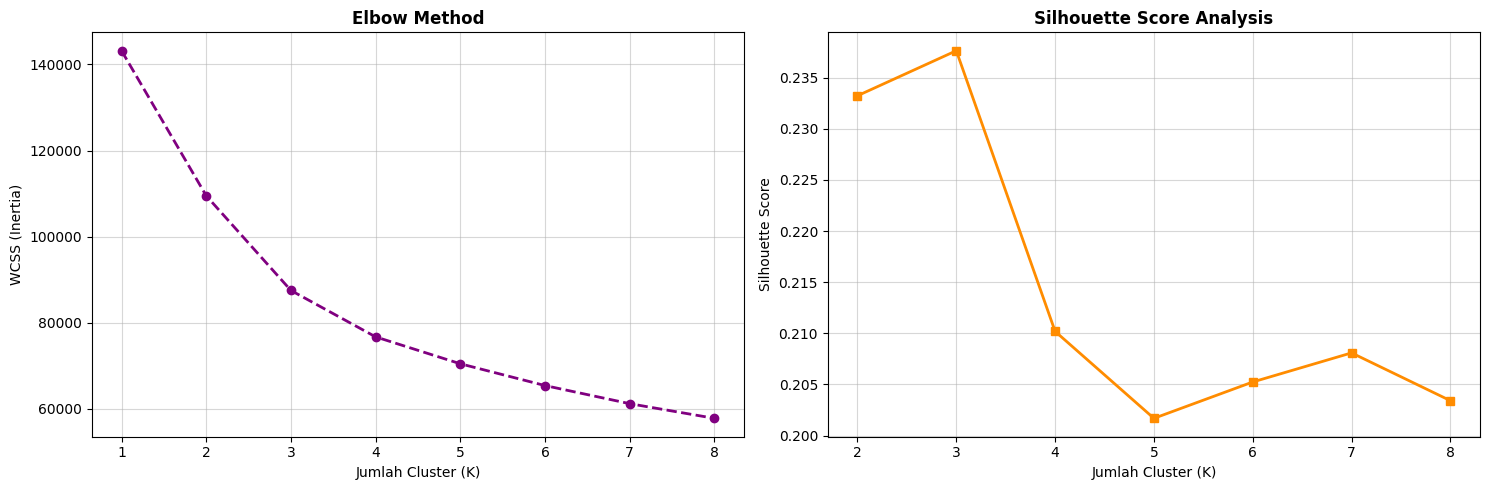

In [13]:
wcss = []
silhouette_coefficients = []
cluster_range = range(2, 9)

print("Sedang menghitung jumlah cluster terbaik, mohon tunggu sebentar...")

kmeans_1 = KMeans(n_clusters=1, random_state=42, n_init=10)
kmeans_1.fit(df_scaled)
wcss.append(kmeans_1.inertia_)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)

    wcss.append(kmeans.inertia_)

    score = silhouette_score(df_scaled, kmeans.labels_)
    silhouette_coefficients.append(score)

print("Perhitungan selesai!")

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, 9), wcss, marker='o', color='purple', linestyle='--', linewidth=2)
plt.title('Elbow Method', fontsize=12, fontweight='bold')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True, alpha=0.5)

plt.subplot(1, 2, 2)
plt.plot(range(2, 9), silhouette_coefficients, marker='s', color='darkorange', linestyle='-', linewidth=2)
plt.title('Silhouette Score Analysis', fontsize=12, fontweight='bold')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

Jumlah kelompok terbaik untuk pelanggan adalah 3 Cluster.

##**Algoritma Clustering**

###**K-Means**

In [14]:
optimum_k = 3
kmeans_model = KMeans(n_clusters=optimum_k, random_state=42, n_init=10)

df_clean['Cluster_KMeans'] = kmeans_model.fit_predict(df_scaled)

print("--- Proses K-Means Clustering Selesai ---")
print("Label cluster berhasil ditambahkan ke kolom 'Cluster_KMeans' pada dataset!")
print("\nJumlah anggota di setiap cluster:")
print(df_clean['Cluster_KMeans'].value_counts().sort_index())

--- Proses K-Means Clustering Selesai ---
Label cluster berhasil ditambahkan ke kolom 'Cluster_KMeans' pada dataset!

Jumlah anggota di setiap cluster:
Cluster_KMeans
0    2043
1    4608
2    2299
Name: count, dtype: int64


###**Hierarchical Clustering**

In [15]:
hierarchical_model = AgglomerativeClustering(n_clusters=3, linkage='ward')

print("Sedang memproses Hierarchical Clustering, mohon tunggu sebentar...")
df_clean['Cluster_Hierarchical'] = hierarchical_model.fit_predict(df_scaled)

print("--- Proses Hierarchical Clustering Selesai ---")
print("Label cluster berhasil ditambahkan ke kolom 'Cluster_Hierarchical'!")
print("\nJumlah anggota di setiap cluster (Hierarchical):")
print(df_clean['Cluster_Hierarchical'].value_counts().sort_index())

Sedang memproses Hierarchical Clustering, mohon tunggu sebentar...
--- Proses Hierarchical Clustering Selesai ---
Label cluster berhasil ditambahkan ke kolom 'Cluster_Hierarchical'!

Jumlah anggota di setiap cluster (Hierarchical):
Cluster_Hierarchical
0    3528
1    3838
2    1584
Name: count, dtype: int64


###**DBSCAN (Density-Based Spatial Clustering of Applications with Noise).**

In [16]:
dbscan_model = DBSCAN(eps=2.5, min_samples=10)

df_clean['Cluster_DBSCAN'] = dbscan_model.fit_predict(df_scaled)

print("--- Proses DBSCAN Clustering Selesai ---")
print("Label cluster berhasil ditambahkan ke kolom 'Cluster_DBSCAN'!")
print("\nJumlah anggota di setiap cluster (DBSCAN):")
print(df_clean['Cluster_DBSCAN'].value_counts().sort_index())

--- Proses DBSCAN Clustering Selesai ---
Label cluster berhasil ditambahkan ke kolom 'Cluster_DBSCAN'!

Jumlah anggota di setiap cluster (DBSCAN):
Cluster_DBSCAN
-1     103
 0    8847
Name: count, dtype: int64


DBSCAN mendeteksi ada 103 data pelanggan sebagai noise (pencilan yang tidak masuk kelompok mana pun) dan memasukkan sisanya (8.847 pelanggan) ke dalam satu kelompok besar (Cluster 0). Hal ini menunjukkan bahwa data perilaku kartu kredit kamu sangat padat dan menyatu, sehingga DBSCAN kesulitan memisahkannya tanpa tunning radius (eps) yang sangat spesifik.

Oleh karena itu, persaingan utama sekarang ada pada K-Means vs Hierarchical Clustering yang sukses membagi pelanggan ke dalam 3 kelompok terpisah.

###**Evaluasi Hasil Clustering**

In [18]:
score_kmeans = silhouette_score(df_scaled, df_clean['Cluster_KMeans'])

score_hierarchical = silhouette_score(df_scaled, df_clean['Cluster_Hierarchical'])

print("--- Hasil Evaluasi Silhouette Score ---")
print(f"Silhouette Score K-Means      : {score_kmeans:.4f}")
print(f"Silhouette Score Hierarchical : {score_hierarchical:.4f}")
print("---------------------------------------")

if score_kmeans > score_hierarchical:
    print("K-Means memiliki struktur pengelompokan yang LEBIH OPTIMAL!")
else:
    print("Hierarchical Clustering memiliki struktur pengelompokan yang LEBIH OPTIMAL!")

--- Hasil Evaluasi Silhouette Score ---
Silhouette Score K-Means      : 0.2376
Silhouette Score Hierarchical : 0.1808
---------------------------------------
K-Means memiliki struktur pengelompokan yang LEBIH OPTIMAL!


Karena K-Means adalah model terbaik, kita akan menggunakan label dari K-Means untuk visualisasi.

##**Visualisasi Cluster menggunakan PCA**

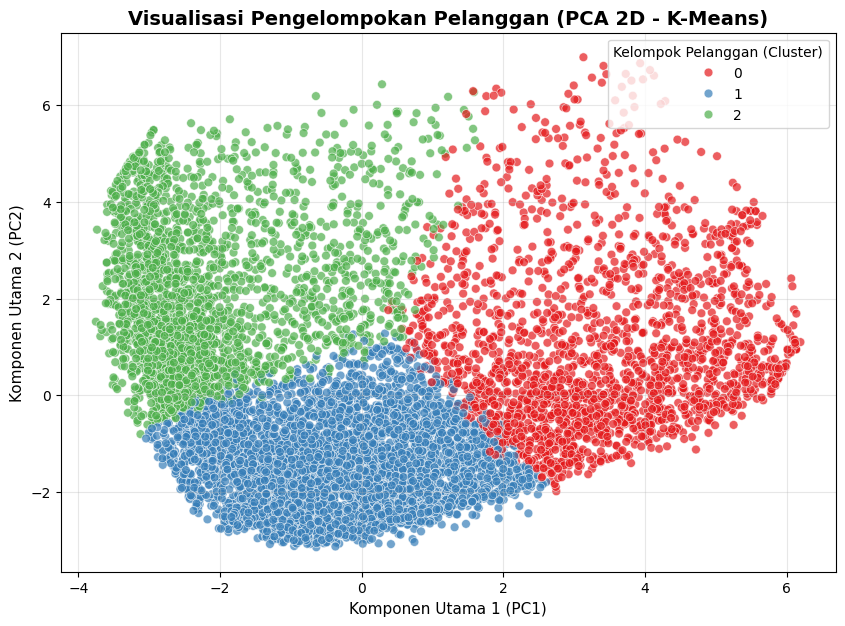

In [19]:
pca = PCA(n_components=2, random_state=42)
pca_elements = pca.fit_transform(df_scaled)

df_pca = pd.DataFrame(data=pca_elements, columns=['PC1', 'PC2'])
df_pca['Cluster'] = df_clean['Cluster_KMeans']

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Cluster',
    data=df_pca,
    palette='Set1',
    alpha=0.7,
    s=40
)

plt.title('Visualisasi Pengelompokan Pelanggan (PCA 2D - K-Means)', fontsize=14, fontweight='bold')
plt.xlabel('Komponen Utama 1 (PC1)', fontsize=11)
plt.ylabel('Komponen Utama 2 (PC2)', fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend(title='Kelompok Pelanggan (Cluster)', loc='upper right')
plt.show()

###**Karakteristik**

In [20]:
kolom_kunci = [
    'BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES',
    'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
    'PURCHASES_FREQUENCY', 'CREDIT_LIMIT', 'PAYMENTS'
]

df_profil = df_clean.groupby('Cluster_KMeans')[kolom_kunci].mean()

print("--- Tabel Karakteristik Rata-Rata per Cluster ---")
display(df_profil)

--- Tabel Karakteristik Rata-Rata per Cluster ---


,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CREDIT_LIMIT,PAYMENTS
Cluster_KMeans,,,,,,,,
0,1714.652581,2087.340303,998.548820,744.631984,392.798466,0.908313,6407.994037,2382.276902
1,563.657448,390.949763,175.344111,204.792813,173.905193,0.457352,3049.137392,692.915729
2,2759.759273,231.210854,140.706585,78.368936,1920.293380,0.185071,5397.703877,1738.345318


Cluster 0: "The Big Spender" (Raja Belanja)

*   Memiliki nilai PURCHASES tertinggi (2.087), frekuensi belanja (PURCHASES_FREQUENCY) sangat aktif yaitu 0.90 (90% waktu digunakan untuk belanja), dan diberikan CREDIT_LIMIT tertinggi (6.407).
*   Ini adalah kelompok pelanggan premium. Mereka sangat konsisten menggunakan kartu kredit untuk transaksi belanja harian maupun cicilan besar, serta sangat taat membayar tagihannya (PAYMENTS tertinggi).



Cluster 1: "The Frugal/Conservative User" (Pengguna Hemat)

*   Memiliki saldo utang (BALANCE) terendah (563), pengeluaran belanja (PURCHASES) yang kecil (~390), dan CREDIT_LIMIT paling rendah (3.049).
*   Ini adalah kelompok mayoritas di dataset kamu. Mereka tipe pengguna kartu kredit yang sangat hemat, pasif, dan berhati-hati. Hanya menggunakan kartu untuk kebutuhan mendesak atau transaksi berskala kecil.



Cluster 2: "The Cash Borrowers" (Peminjam Uang Tunai)

*   Nilai penarikan tunai (CASH_ADVANCE) melesat sangat tinggi (1.920) dibandingkan cluster lain, namun pengeluaran belanjanya (PURCHASES) justru sangat rendah (231). Saldo utang berjalan mereka (BALANCE) paling bengkak (2.759).
*   Kelompok ini unik. Mereka tidak menggunakan kartu kredit untuk berbelanja barang, melainkan menggunakannya seperti "pinjaman online/ATM darurat" untuk menarik uang tunai secara langsung.



## **Conclusion**

Berdasarkan seluruh end-to-end pipeline machine learning yang telah dibangun untuk data perilaku kartu kredit (`clusteringmidterm.csv`), dapat ditarik beberapa kesimpulan utama:

1. **Jumlah Kelompok Optimal:** Berdasarkan evaluasi Elbow Method dan Silhouette Score, jumlah pembagian pelanggan terbaik adalah **3 Cluster**.
2. **Algoritma Terbaik:** **K-Means Clustering** terbukti menjadi model terbaik dengan Silhouette Score tertinggi sebesar **0.2376**, mengungguli Hierarchical Clustering (0.1808) dan DBSCAN yang cenderung sensitif terhadap kepadatan data terpusat.
3. **Rekomendasi Strategi Bisnis (Marketing Action):**
   * **Cluster 0 (Big Spender):** Berikan program loyalitas (cashback besar, poin reward, atau akses eksklusif) agar mereka semakin loyal berbelanja.
   * **Cluster 1 (Pengguna Hemat):** Berikan promo potongan harga atau cicilan 0% di merchant populer untuk merangsang hasrat belanja mereka.
   * **Cluster 2 (Peminjam Tunai):** Berikan edukasi finansial atau tawarkan produk pinjaman pribadi dengan bunga yang bersaing agar saldo utang mereka tetap sehat terkendali.